In [122]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [620]:
tickers = ["GOOG", "MSFT", "JPM", "GEV"]

data = yf.download(tickers=tickers, period="3y")["Close"]
returns = data.pct_change().dropna()

[*********************100%***********************]  4 of 4 completed


In [621]:
returns.std(0)

Ticker
GEV     0.033378
GOOG    0.018686
JPM     0.015982
MSFT    0.015132
dtype: float64

[*********************100%***********************]  1 of 1 completed


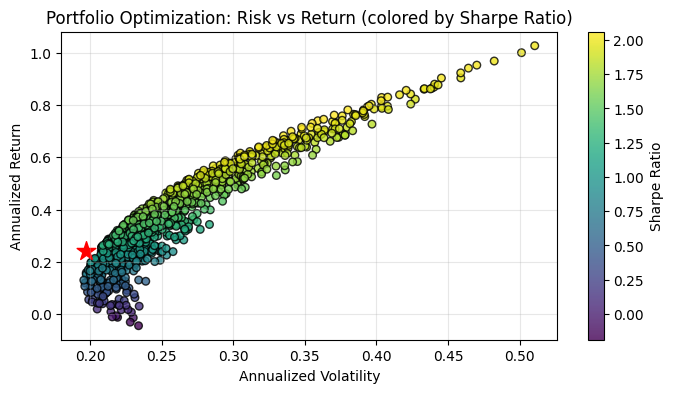

In [625]:
num_portfolios = 1000

weights = np.random.dirichlet(np.ones(len(tickers)), size=num_portfolios)
# sharpe_ratios = [((weights[i] @ (returns.mean() - rf)) / np.sqrt(weights[i] @ returns.cov() @ weights[i].T)) for i in range(num_portfolios)]

rf = (1 + 0.03) ** (1 / 252) - 1

return_covariance = returns.cov()
return_mean = returns.mean() - rf

# Create a scatter plot of portfolio volatility vs return with Sharpe ratio as color
portfolio_returns = weights @ (return_mean - rf) * 252
portfolio_volatility = np.array([np.sqrt(weights[i] @ return_covariance @ weights[i].T) * np.sqrt(252) for i in range(num_portfolios)])
sharpe_ratios = portfolio_returns / portfolio_volatility


# Calculate SPY metrics for comparison
SPY_data = yf.download(tickers="QQQ", period="3y")["Close"]
SPY_returns = SPY_data.pct_change().dropna()

rf = (1 + 0.03) ** (1/252) - 1  # Convert annual risk-free rate to daily

SPY_ANN_RETURN = SPY_returns.mean() * 252
SPY_ANN_VOL = SPY_returns.std() * np.sqrt(252)
SPY_SHARPE = (SPY_ANN_RETURN - rf) / SPY_ANN_VOL


plt.figure(figsize=(8, 4))
plt.scatter(portfolio_volatility, portfolio_returns, c=sharpe_ratios, cmap='viridis', s=30, alpha=0.8, edgecolors='black')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(SPY_ANN_VOL, SPY_ANN_RETURN, color='red', marker='*', s=200, label='QQQ_Portfolio')

plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')

plt.title('Portfolio Optimization: Risk vs Return (colored by Sharpe Ratio)')
plt.grid(True, alpha=0.3)
plt.show()

In [626]:
df = pd.DataFrame(weights, columns=list(data.columns))
df["Sharpe_Ratio"] = sharpe_ratios
df["Portfolio_Volatility"] = portfolio_volatility
df["Portfolio_Return"] = portfolio_returns

In [628]:
df.sort_values(by="Sharpe_Ratio", ascending=False).head()

,GEV,GOOG,JPM,MSFT,Sharpe_Ratio,Portfolio_Volatility,Portfolio_Return
184,0.570577,0.332335,0.089397,0.007691,2.059850,0.359002,0.739489
860,0.625295,0.320759,0.034852,0.019094,2.055221,0.379974,0.780931
403,0.516911,0.365664,0.112402,0.005023,2.054970,0.340333,0.699373
997,0.536322,0.367314,0.085959,0.010405,2.054643,0.347737,0.714475
262,0.549239,0.401532,0.036547,0.012683,2.054546,0.355053,0.729474


In [629]:
df.sort_values(by="Portfolio_Return", ascending=False).head()

,GEV,GOOG,JPM,MSFT,Sharpe_Ratio,Portfolio_Volatility,Portfolio_Return
20,0.954916,0.034588,0.009520,0.000977,2.010153,0.510523,1.026229
564,0.934741,0.023693,0.013231,0.028335,1.994071,0.501280,0.999588
633,0.889506,0.059900,0.027400,0.023194,2.006796,0.482233,0.967743
576,0.859297,0.094810,0.040036,0.005857,2.025355,0.470060,0.952039
151,0.845530,0.092279,0.058252,0.003938,2.026245,0.464200,0.940583


In [630]:
df.sort_values(by="Portfolio_Volatility", ascending=True).head()

,GEV,GOOG,JPM,MSFT,Sharpe_Ratio,Portfolio_Volatility,Portfolio_Return
873,0.003484,0.190153,0.427267,0.379096,0.664991,0.195581,0.130060
757,0.011239,0.118925,0.422683,0.447153,0.544289,0.196265,0.106825
631,0.015385,0.202690,0.326389,0.455536,0.607749,0.196504,0.119425
590,0.031775,0.198382,0.380201,0.389642,0.770983,0.197253,0.152079
550,0.012633,0.220618,0.444428,0.322322,0.804467,0.197262,0.158691
